# Colab E — TensorFlow: All Four Variants
## 3-Layer Deep Neural Network for Nonlinear Regression

---

## What is this Colab about?

This Colab builds the same 3-layer neural network four different ways using TensorFlow/Keras.
The equation, architecture, and data are identical to all previous Colabs.

The four variants show TensorFlow's full spectrum — from raw low-level ops all the way to the simplest high-level API:

| Variant | Approach | Analogous to |
|---|---|---|
| **E-i** | TensorFlow low-level — no Keras at all | Colab b (manual PyTorch) |
| **E-ii** | Keras built-in layers with manual training loop | Colab c (PyTorch built-in) |
| **E-iii** | Keras Functional API | New concept — graph-style model building |
| **E-iv** | Keras Sequential high-level API | Colab d (highest abstraction) |

All four reach the same result. The only thing changing is how much TensorFlow does for you.

---


---
## Shared Setup — Data Generation (Used by All Variants)

We generate the data once and reuse it across all four variants.
Same equation: **y = sin(x1) + x2² + x1·x3**
Same 1000 samples, same noise, same PCA 4D plot.


TensorFlow version: 2.19.0
X shape: (1000, 3)
y shape: (1000, 1)


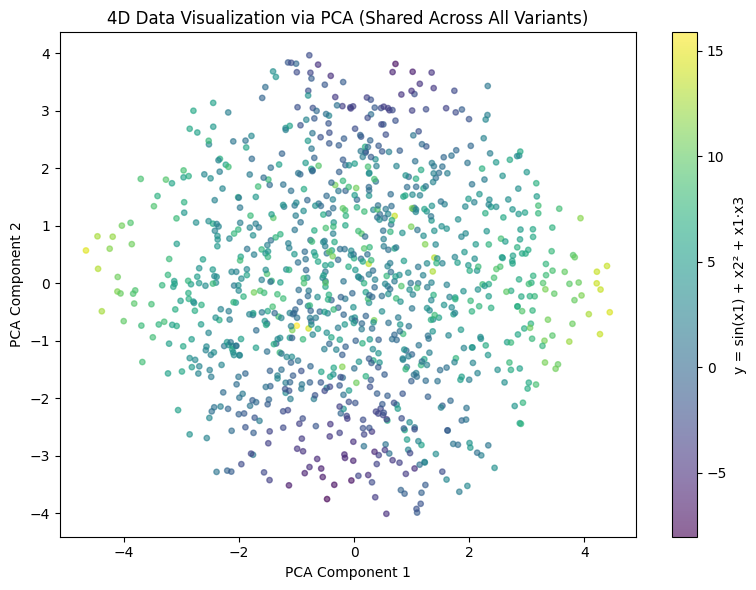

In [1]:
# ============================================================
# SHARED SETUP: Imports + Data Generation
# Used by all four TensorFlow variants below
# ============================================================

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

# --- Generate synthetic data ---
N = 1000
x1 = np.random.uniform(-3, 3, N)
x2 = np.random.uniform(-3, 3, N)
x3 = np.random.uniform(-3, 3, N)

y = np.sin(x1) + x2**2 + x1 * x3
y += 0.1 * np.random.randn(N)

X_np = np.column_stack([x1, x2, x3]).astype(np.float32)
y_np = y.reshape(-1, 1).astype(np.float32)

# Convert to TensorFlow tensors
X_tf = tf.constant(X_np, dtype=tf.float32)
y_tf = tf.constant(y_np, dtype=tf.float32)

print("X shape:", X_np.shape)
print("y shape:", y_np.shape)

# --- 4D Plot using PCA ---
pca  = PCA(n_components=2)
X_2d = pca.fit_transform(X_np)

fig = plt.figure(figsize=(8, 6))
ax  = fig.add_subplot(111)
scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1],
                     c=y_np.flatten(), cmap='viridis', alpha=0.6, s=15)
plt.colorbar(scatter, label='y = sin(x1) + x2² + x1·x3')
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_title('4D Data Visualization via PCA (Shared Across All Variants)')
plt.tight_layout()
plt.show()

# --- Helper: plot results (shared across all variants) ---
def plot_results(y_actual, y_predicted, loss_history, title_suffix):
    """Reusable plotting function for all 4 variants."""

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Loss curve
    axes[0].plot(loss_history, linewidth=1.5)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MSE Loss')
    axes[0].set_title(f'Loss Curve — {title_suffix}')
    axes[0].set_yscale('log')
    axes[0].grid(True, alpha=0.3)

    # Predicted vs Actual
    axes[1].scatter(y_actual.flatten(), y_predicted.flatten(),
                    alpha=0.3, s=10)
    mn = min(y_actual.min(), y_predicted.min())
    mx = max(y_actual.max(), y_predicted.max())
    axes[1].plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect')
    axes[1].set_xlabel('Actual y')
    axes[1].set_ylabel('Predicted y')
    axes[1].set_title(f'Predicted vs Actual — {title_suffix}')
    axes[1].legend()

    # 4D comparison (predicted)
    sc = axes[2].scatter(X_2d[:, 0], X_2d[:, 1],
                         c=y_predicted.flatten(), cmap='plasma', alpha=0.6, s=15)
    plt.colorbar(sc, ax=axes[2], label='Predicted y')
    axes[2].set_title(f'4D Predicted — {title_suffix}')
    axes[2].set_xlabel('PCA Component 1')
    axes[2].set_ylabel('PCA Component 2')

    plt.suptitle(title_suffix, fontsize=13)
    plt.tight_layout()
    plt.show()

    # Metrics
    ss_res = np.sum((y_actual.flatten() - y_predicted.flatten()) ** 2)
    ss_tot = np.sum((y_actual.flatten() - np.mean(y_actual)) ** 2)
    r2  = 1 - ss_res / ss_tot
    mse = np.mean((y_actual.flatten() - y_predicted.flatten()) ** 2)
    print(f"  Final MSE : {mse:.4f}")
    print(f"  R² Score  : {r2:.4f}")
    return r2


---
---
# Variant E-i — TensorFlow Low Level (No Keras)

## What is this variant about?

This is TensorFlow at its most raw — no `keras.layers`, no `model.fit()`, no built-in anything.
We manually declare weight tensors as `tf.Variable`, write the forward pass using `tf.matmul`,
compute gradients using `tf.GradientTape`, and apply updates by hand.

This is the TensorFlow equivalent of **Colab b** (PyTorch from scratch).

**`tf.GradientTape`** is TensorFlow's equivalent of PyTorch autograd.
You wrap your forward pass inside a `with tf.GradientTape()` block —
TensorFlow records every operation on `tf.Variable` tensors inside that block.
When you call `tape.gradient(loss, variables)`, it computes all gradients automatically.

You never write a single derivative by hand but you manage the tape and updates yourself.


VARIANT E-i: TensorFlow Low Level
Weight shapes:
  Variable:0: (3, 16)
  Variable:0: (1, 16)
  Variable:0: (16, 8)
  Variable:0: (1, 8)
  Variable:0: (8, 1)
  Variable:0: (1, 1)
Epoch    1 / 500  |  Loss: 31.1536
Epoch  100 / 500  |  Loss: 1.9855
Epoch  200 / 500  |  Loss: 1.1139
Epoch  300 / 500  |  Loss: 0.7525
Epoch  400 / 500  |  Loss: 0.1592
Epoch  500 / 500  |  Loss: 0.1119

Variant E-i Training Complete!


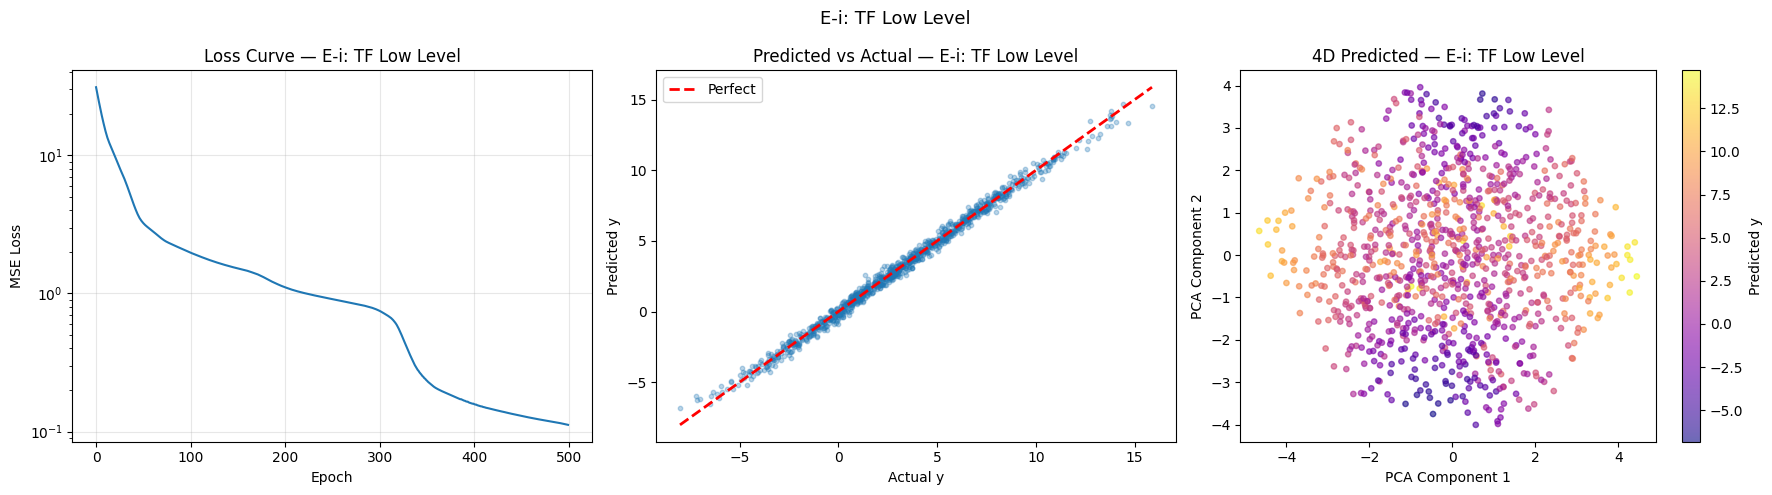

  Final MSE : 0.1115
  R² Score  : 0.9934


In [2]:
# ============================================================
# VARIANT E-i: TensorFlow Low Level — No Keras
# ============================================================

print("=" * 55)
print("VARIANT E-i: TensorFlow Low Level")
print("=" * 55)

# --- Initialize weights manually as tf.Variable ---
# tf.Variable = a tensor whose value can be updated during training
# This is the TF equivalent of nn.Parameter in PyTorch
# He initialization: scale by sqrt(2 / fan_in)

tf.random.set_seed(42)

W1_ei = tf.Variable(tf.random.normal([3, 16])  * tf.sqrt(2.0 / 3),  dtype=tf.float32)
b1_ei = tf.Variable(tf.zeros([1, 16]),  dtype=tf.float32)

W2_ei = tf.Variable(tf.random.normal([16, 8]) * tf.sqrt(2.0 / 16), dtype=tf.float32)
b2_ei = tf.Variable(tf.zeros([1, 8]),   dtype=tf.float32)

W3_ei = tf.Variable(tf.random.normal([8, 1])  * tf.sqrt(2.0 / 8),  dtype=tf.float32)
b3_ei = tf.Variable(tf.zeros([1, 1]),   dtype=tf.float32)

variables_ei = [W1_ei, b1_ei, W2_ei, b2_ei, W3_ei, b3_ei]

print("Weight shapes:")
for v in variables_ei:
    print(f"  {v.name}: {v.shape}")

# --- Forward pass function ---
def forward_ei(X):
    """
    Manual forward pass using tf.matmul and tf.nn.relu.
    No Keras layers — raw TensorFlow operations only.
    """
    Z1 = tf.matmul(X, W1_ei) + b1_ei   # Linear: (1000,3) x (3,16) = (1000,16)
    A1 = tf.nn.relu(Z1)                  # ReLU activation

    Z2 = tf.matmul(A1, W2_ei) + b2_ei   # Linear: (1000,16) x (16,8) = (1000,8)
    A2 = tf.nn.relu(Z2)                  # ReLU activation

    Z3 = tf.matmul(A2, W3_ei) + b3_ei   # Linear: (1000,8) x (8,1) = (1000,1)
    return Z3                             # No activation — regression output

# --- Training loop ---
# Adam optimizer — same as Colabs c and d
optimizer_ei = tf.optimizers.Adam(learning_rate=0.01)
epochs_ei    = 500
loss_hist_ei = []

for epoch in range(1, epochs_ei + 1):

    # tf.GradientTape records all operations on tf.Variables inside this block
    # When we call tape.gradient(), it walks back through the recorded ops
    # and computes derivatives — same concept as loss.backward() in PyTorch
    with tf.GradientTape() as tape:
        y_pred = forward_ei(X_tf)
        loss   = tf.reduce_mean(tf.square(y_pred - y_tf))  # MSE

    # Compute gradients for all variables at once
    grads = tape.gradient(loss, variables_ei)

    # Apply gradients — equivalent to optimizer.step() in PyTorch
    # zip pairs each gradient with its corresponding variable
    optimizer_ei.apply_gradients(zip(grads, variables_ei))

    loss_hist_ei.append(loss.numpy())

    if epoch % 100 == 0 or epoch == 1:
        print(f"Epoch {epoch:>4} / {epochs_ei}  |  Loss: {loss.numpy():.4f}")

print("\nVariant E-i Training Complete!")
y_pred_ei = forward_ei(X_tf).numpy()
r2_ei = plot_results(y_np, y_pred_ei, loss_hist_ei, "E-i: TF Low Level")


---
---
# Variant E-ii — Keras Built-in Layers + Manual Training Loop

## What is this variant about?

Now we use Keras `layers.Dense` (the TensorFlow equivalent of PyTorch's `nn.Linear`) to define
the network, but we still write the training loop manually using `tf.GradientTape`.

This is a middle ground — built-in layer convenience for model definition,
but manual control over the training process.

**`layers.Dense(units, activation)`** is a fully connected layer.
It handles weight initialization, stores weights internally, and computes `Z = X @ W + b` automatically.

The training loop structure is identical to Variant E-i — `GradientTape`, `tape.gradient`,
`optimizer.apply_gradients` but now `model.trainable_variables` gives us all weights automatically
instead of managing a manual list.


VARIANT E-ii: Keras Layers + Manual Training Loop
Model summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209 (836.00 B)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch    1 / 500  |  Loss: 26.4778
Epoch  100 / 500  |  Loss: 0.7342
Epoch  200 / 500  |  Loss: 0.3830
Epoch  300 / 500  |  Loss: 0.2571
Epoch  400 / 500  |  Loss: 0.1981
Epoch  500 / 500  |  Loss: 0.1558

Variant E-ii Training Complete!


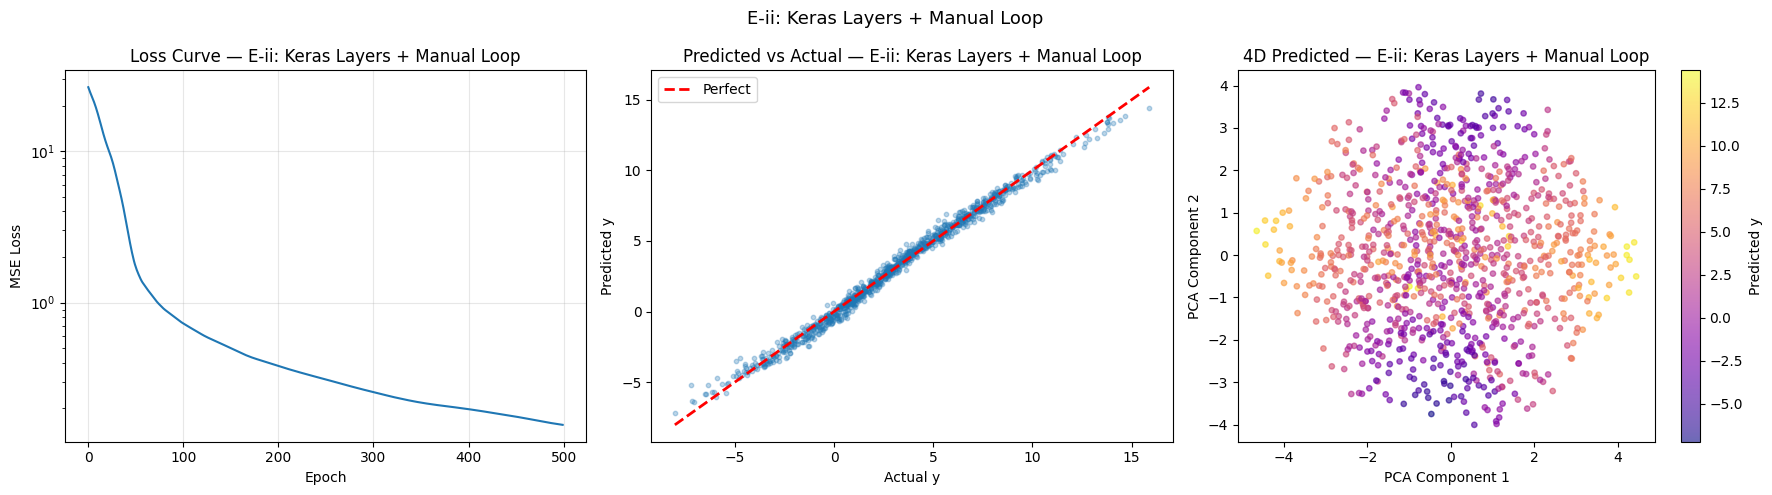

  Final MSE : 0.1554
  R² Score  : 0.9907


In [3]:
# ============================================================
# VARIANT E-ii: Keras Built-in Layers + Manual Training Loop
# ============================================================

print("=" * 55)
print("VARIANT E-ii: Keras Layers + Manual Training Loop")
print("=" * 55)

# --- Build model using Keras layers ---
# keras.Sequential stacks layers — identical concept to PyTorch nn.Sequential
# Dense = fully connected layer (equivalent to nn.Linear)
# activation='relu' applies ReLU inside the layer automatically
model_eii = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(3,)),  # Layer 1
    tf.keras.layers.Dense(8,  activation='relu'),                     # Layer 2
    tf.keras.layers.Dense(1)                                          # Output — no activation
])

print("Model summary:")
model_eii.summary()

# --- Manual training loop with GradientTape ---
optimizer_eii = tf.keras.optimizers.Adam(learning_rate=0.01)
epochs_eii    = 500
loss_hist_eii = []

for epoch in range(1, epochs_eii + 1):

    with tf.GradientTape() as tape:
        y_pred = model_eii(X_tf, training=True)   # training=True enables dropout if present
        loss   = tf.reduce_mean(tf.square(y_pred - y_tf))

    # model.trainable_variables gives us ALL weights and biases in one list
    # No need to manually list W1, b1, W2, b2 etc. like in E-i
    grads = tape.gradient(loss, model_eii.trainable_variables)
    optimizer_eii.apply_gradients(zip(grads, model_eii.trainable_variables))

    loss_hist_eii.append(loss.numpy())

    if epoch % 100 == 0 or epoch == 1:
        print(f"Epoch {epoch:>4} / {epochs_eii}  |  Loss: {loss.numpy():.4f}")

print("\nVariant E-ii Training Complete!")
y_pred_eii = model_eii(X_tf, training=False).numpy()
r2_eii = plot_results(y_np, y_pred_eii, loss_hist_eii, "E-ii: Keras Layers + Manual Loop")


---
---
# Variant E-iii — Keras Functional API

## What is this variant about?

The Functional API is a different way of building Keras models.
Instead of stacking layers in a list (Sequential), you **explicitly connect layers
by passing tensors through them** like building a computation graph by hand.

Why does this matter? Sequential only works for simple straight-line architectures.
The Functional API supports:
- Multiple inputs or outputs
- Shared layers (same layer used in multiple places)
- Skip connections (like in ResNet)
- Branching and merging paths

For our simple 3-layer network the result is identical to Sequential —
but knowing the Functional API is essential for any non-trivial architecture.

The pattern is:
```python
inputs = tf.keras.Input(shape=(3,))      # define input
x = Dense(16, activation='relu')(inputs) # call layer AS A FUNCTION on a tensor
x = Dense(8,  activation='relu')(x)
outputs = Dense(1)(x)
model = tf.keras.Model(inputs, outputs)  # package into a model
```

Once built, we use `model.compile()` and `model.fit()`  no manual training loop needed.


VARIANT E-iii: Keras Functional API
Model summary:


Model: "FunctionalNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209 (836.00 B)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

Starting loss : 19.4544
Final loss    : 0.0271

Variant E-iii Training Complete!


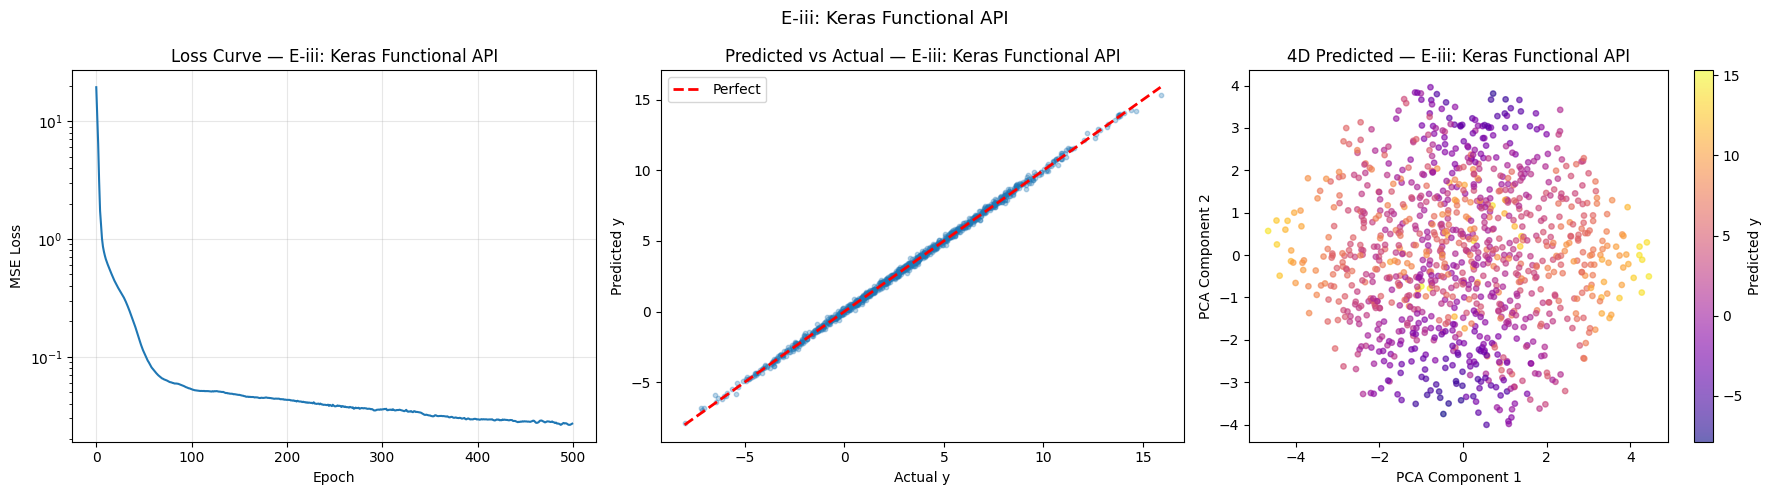

  Final MSE : 0.0258
  R² Score  : 0.9985


In [4]:
# ============================================================
# VARIANT E-iii: Keras Functional API
# ============================================================

print("=" * 55)
print("VARIANT E-iii: Keras Functional API")
print("=" * 55)

# --- Build model using Functional API ---

# Step 1: Define a symbolic input tensor
# This doesn't hold data yet — it's a placeholder describing the shape
inputs_eiii = tf.keras.Input(shape=(3,), name='input_layer')

# Step 2: Call layers as functions on tensors
# Each layer call returns a new tensor — you're building a graph
x = tf.keras.layers.Dense(16, activation='relu', name='hidden_1')(inputs_eiii)
x = tf.keras.layers.Dense(8,  activation='relu', name='hidden_2')(x)
outputs_eiii = tf.keras.layers.Dense(1, name='output')(x)

# Step 3: Package input and output tensors into a Model
# Keras traces the graph from inputs to outputs automatically
model_eiii = tf.keras.Model(inputs=inputs_eiii, outputs=outputs_eiii, name='FunctionalNet')

print("Model summary:")
model_eiii.summary()

# --- Compile: attach loss function and optimizer ---
# compile() is Keras's way of configuring training
# After compile, model.fit() handles the entire training loop
model_eiii.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='mse'   # mean squared error — same as all previous variants
)

# --- Train using model.fit() ---
# fit() handles: batching, forward pass, loss, backward, weight update
# verbose=0 silences per-epoch output (we capture history instead)
history_eiii = model_eiii.fit(
    X_np, y_np,
    epochs=500,
    batch_size=64,       # mini-batch gradient descent
    verbose=0            # suppress output — we'll plot instead
)

# history.history['loss'] contains loss at every epoch
loss_hist_eiii = history_eiii.history['loss']
print(f"Starting loss : {loss_hist_eiii[0]:.4f}")
print(f"Final loss    : {loss_hist_eiii[-1]:.4f}")

print("\nVariant E-iii Training Complete!")
y_pred_eiii = model_eiii.predict(X_np, verbose=0)
r2_eiii = plot_results(y_np, y_pred_eiii, loss_hist_eiii, "E-iii: Keras Functional API")


---
---
# Variant E-iv — Keras Sequential High-Level API (Simplest)

## What is this variant about?

This is TensorFlow at its highest level of abstraction — the simplest way to build
and train a neural network in the entire TF/Keras ecosystem.

We use `keras.Sequential` to define the model (same as E-ii) but now we also use
`model.compile()` and `model.fit()` instead of writing any training loop ourselves.

We also add two new production features:

**Early Stopping** — monitors the loss and stops training automatically when improvement
stalls. No need to guess the right number of epochs — the model stops when it's done.

**Model Checkpoint** — saves the best version of the model to disk during training.
If the model starts overfitting after epoch 200 but was best at epoch 180, the checkpoint
saves the epoch-180 weights so you don't lose them.

This is analogous to **Colab d (PyTorch Lightning)** — maximum abstraction,
minimum boilerplate, production-ready features built in.


VARIANT E-iv: Keras Sequential High-Level API
Model summary:


Model: "SequentialNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209 (836.00 B)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)


Epoch 401: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.

Epoch 531: ReduceLROnPlateau reducing learning rate to 0.0024999999441206455.

Epoch 551: ReduceLROnPlateau reducing learning rate to 0.0012499999720603228.

Epoch 575: ReduceLROnPlateau reducing learning rate to 0.0006249999860301614.

Epoch 596: ReduceLROnPlateau reducing learning rate to 0.0003124999930150807.

Epoch 617: ReduceLROnPlateau reducing learning rate to 0.00015624999650754035.

Epoch 657: ReduceLROnPlateau reducing learning rate to 7.812499825377017e-05.

Epoch 678: ReduceLROnPlateau reducing learning rate to 3.9062499126885086e-05.

Epoch 700: ReduceLROnPlateau reducing learning rate to 1.9531249563442543e-05.

Epoch 720: ReduceLROnPlateau reducing learning rate to 9.765624781721272e-06.

Epoch 740: ReduceLROnPlateau reducing learning rate to 4.882812390860636e-06.

Epoch 774: ReduceLROnPlateau reducing learning rate to 2.441406195430318e-06.

Epoch 794: ReduceLROnPlateau reducing learning ra

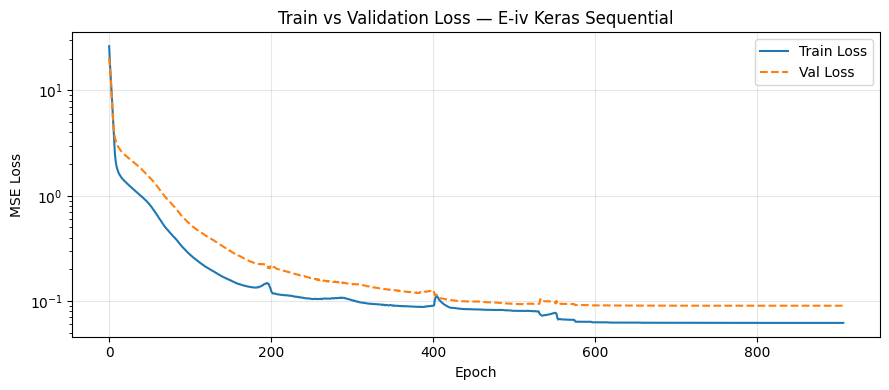


Variant E-iv Training Complete!


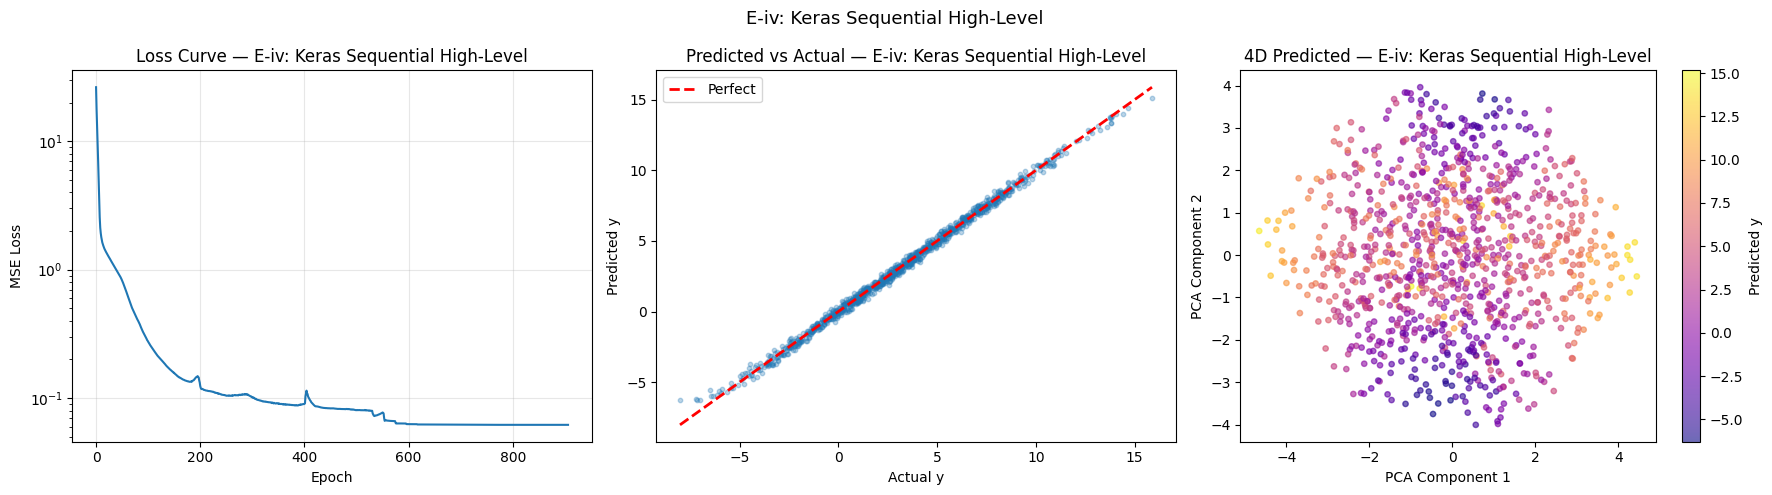

  Final MSE : 0.0647
  R² Score  : 0.9961


In [5]:
# ============================================================
# VARIANT E-iv: Keras Sequential High-Level API
# ============================================================

print("=" * 55)
print("VARIANT E-iv: Keras Sequential High-Level API")
print("=" * 55)

# --- Build model ---
# Identical Sequential structure to E-ii
# The difference is entirely in HOW we train it
model_eiv = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(3,), name='hidden_1'),
    tf.keras.layers.Dense(8,  activation='relu', name='hidden_2'),
    tf.keras.layers.Dense(1,  name='output')
], name='SequentialNet')

print("Model summary:")
model_eiv.summary()

# --- Compile ---
model_eiv.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='mse',
    metrics=['mae']   # also track Mean Absolute Error for insight
)

# --- Callbacks ---
# Callbacks are functions Keras calls at specific points during training

# EarlyStopping: stops training if 'val_loss' doesn't improve for 50 epochs
# restore_best_weights=True: reloads the best weights when training ends
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=50,
    restore_best_weights=True,
    verbose=1
)

# ReduceLROnPlateau: halves learning rate if loss stalls for 20 epochs
# Same concept as Colabs c and d
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=20,
    verbose=1
)

# --- Train ---
# validation_split=0.1 holds out 10% of data as a validation set
# Keras evaluates on this after each epoch — used by EarlyStopping
history_eiv = model_eiv.fit(
    X_np, y_np,
    epochs=1000,              # high ceiling — EarlyStopping will stop us early
    batch_size=64,
    validation_split=0.1,     # 10% held out for validation
    callbacks=[early_stop, reduce_lr],
    verbose=0
)

loss_hist_eiv = history_eiv.history['loss']
val_loss_eiv  = history_eiv.history['val_loss']
actual_epochs = len(loss_hist_eiv)

print(f"\nTraining stopped at epoch {actual_epochs} (EarlyStopping)")
print(f"Starting loss : {loss_hist_eiv[0]:.4f}")
print(f"Final loss    : {loss_hist_eiv[-1]:.4f}")

# --- Plot loss + validation loss ---
plt.figure(figsize=(9, 4))
plt.plot(loss_hist_eiv,  label='Train Loss', linewidth=1.5)
plt.plot(val_loss_eiv,   label='Val Loss',   linewidth=1.5, linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Train vs Validation Loss — E-iv Keras Sequential')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nVariant E-iv Training Complete!")
y_pred_eiv = model_eiv.predict(X_np, verbose=0)
r2_eiv = plot_results(y_np, y_pred_eiv, loss_hist_eiv, "E-iv: Keras Sequential High-Level")


---
---
# Final Comparison — All Variants + All Colabs


In [6]:
# ============================================================
# FINAL: Cross-variant and Cross-Colab Comparison
# ============================================================

print("=" * 55)
print("FULL COMPARISON SUMMARY")
print("=" * 55)
print()
print("TensorFlow Variants (Colab E):")
print(f"  E-i   TF Low Level (manual vars + GradientTape) : R² {r2_ei:.3f}")
print(f"  E-ii  Keras Layers + Manual Loop                : R² {r2_eii:.3f}")
print(f"  E-iii Keras Functional API + model.fit()        : R² {r2_eiii:.3f}")
print(f"  E-iv  Keras Sequential + EarlyStopping          : R² {r2_eiv:.3f}")
print()
print("All Colabs (same architecture, same equation):")
print("  Colab a — NumPy manual backprop                  : R² ~0.92")
print("  Colab b — PyTorch manual weights                 : R² ~0.92")
print("  Colab c — PyTorch built-in + Adam + scheduler    : R² ~0.95")
print("  Colab d — PyTorch Lightning                      : R² ~0.95")
print("  Colab e — TensorFlow (all variants above)")
print()
print("Key insight: Same math, same architecture, same result.")
print("The only difference is how much the framework does for you.")


FULL COMPARISON SUMMARY

TensorFlow Variants (Colab E):
  E-i   TF Low Level (manual vars + GradientTape) : R² 0.993
  E-ii  Keras Layers + Manual Loop                : R² 0.991
  E-iii Keras Functional API + model.fit()        : R² 0.998
  E-iv  Keras Sequential + EarlyStopping          : R² 0.996

All Colabs (same architecture, same equation):
  Colab a — NumPy manual backprop                  : R² ~0.92
  Colab b — PyTorch manual weights                 : R² ~0.92
  Colab c — PyTorch built-in + Adam + scheduler    : R² ~0.95
  Colab d — PyTorch Lightning                      : R² ~0.95
  Colab e — TensorFlow (all variants above)

Key insight: Same math, same architecture, same result.
The only difference is how much the framework does for you.
